In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import random 
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [2]:
random.seed(42)
np.random.seed(42)

def generate_transactions(n_transactions=50000):
    transactions = []
    
    n_users = 500
    user_avg_amounts = {i: random.uniform(500, 15000) for i in range(n_users)}
    
    for i in range(n_transactions):
        sender_id = random.randint(0, n_users - 1)
        receiver_id = random.randint(0, n_users - 1)
        while receiver_id == sender_id:
            receiver_id = random.randint(0, n_users - 1)
        
        # Time features
        hour = random.randint(0, 23)
        day_of_week = random.randint(0, 6)
        is_night = 1 if (hour >= 22 or hour <= 6) else 0
        is_weekend = 1 if day_of_week >= 5 else 0
        
        # Amount features
        user_avg = user_avg_amounts[sender_id]
        amount_ratio = random.uniform(0.1, 20)
        amount = user_avg * amount_ratio
        
        # Frequency features
        freq_1hr = random.randint(0, 8)
        freq_24hr = random.randint(0, 15)
        
        # Receiver features
        is_new_receiver = random.choice([0, 1])
        
        # Calculate fraud score
        fraud_score = 0
        
        if amount_ratio > 10:
            fraud_score += 40
        elif amount_ratio > 5:
            fraud_score += 20

        if freq_1hr >= 5:
            fraud_score += 30
        elif freq_1hr >= 3:
            fraud_score += 15

        if is_night and is_new_receiver:
            fraud_score += 25
        elif is_night:
            fraud_score += 10
        elif is_new_receiver:
            fraud_score += 15

        if is_weekend and is_night:
            fraud_score += 10

        # Determine fraud label
        if fraud_score >= 70:
            is_fraud = 1
        elif fraud_score >= 40:
            is_fraud = 1 if random.random() < 0.3 else 0
        else:
            is_fraud = 1 if random.random() < 0.02 else 0

        transactions.append({
            'amount': round(amount, 2),
            'hour': hour,
            'day_of_week': day_of_week,
            'is_night': is_night,
            'is_weekend': is_weekend,
            'freq_1hr': freq_1hr,
            'freq_24hr': freq_24hr,
            'is_new_receiver': is_new_receiver,
            'amount_ratio': round(amount_ratio, 2),
            'user_avg_amount': round(user_avg, 2),
            'is_fraud': is_fraud
        })
    
    return pd.DataFrame(transactions)

df = generate_transactions(50000)

print("Dataset Shape:", df.shape)
print("\nFraud Distribution:")
print(df['is_fraud'].value_counts())
print(f"\nFraud Rate: {df['is_fraud'].mean()*100:.2f}%")
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (50000, 11)

Fraud Distribution:
is_fraud
0    26963
1    23037
Name: count, dtype: int64

Fraud Rate: 46.07%

First 5 rows:
      amount  hour  day_of_week  is_night  is_weekend  freq_1hr  freq_24hr  \
0   32559.70     0            3         1           0         0          2   
1  102501.90     1            2         1           0         3         14   
2  257072.09     8            6         0           1         6          8   
3    7476.79    23            4         1           0         5          7   
4    8408.64     0            1         1           0         0          4   

   is_new_receiver  amount_ratio  user_avg_amount  is_fraud  
0                1         11.88          2741.02         1  
1                1          7.64         13409.17         0  
2                0         19.03         13509.52         1  
3                0          1.14          6578.76         0  
4                0          4.07          2067.39         0  


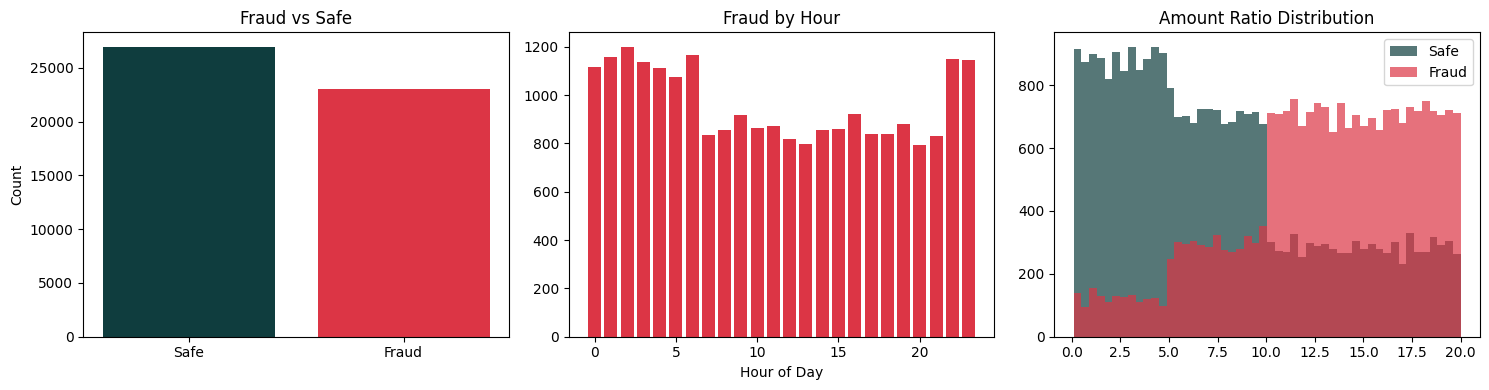

Charts done!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud vs Safe
axes[0].bar(['Safe', 'Fraud'],
            df['is_fraud'].value_counts().values,
            color=['#0F3D3E', '#dc3545'])
axes[0].set_title('Fraud vs Safe')
axes[0].set_ylabel('Count')

# Fraud by hour
fraud_by_hour = df[df['is_fraud']==1]['hour'].value_counts().sort_index()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#dc3545')
axes[1].set_title('Fraud by Hour')
axes[1].set_xlabel('Hour of Day')

# Amount distribution
axes[2].hist(df[df['is_fraud']==0]['amount_ratio'],
             bins=50, alpha=0.7, color='#0F3D3E', label='Safe')
axes[2].hist(df[df['is_fraud']==1]['amount_ratio'],
             bins=50, alpha=0.7, color='#dc3545', label='Fraud')
axes[2].set_title('Amount Ratio Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()
print("Charts done!")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print("Features:", X.columns.tolist())
print("Feature count:", X.shape[1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost
print("\nTraining XGBoost...")
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])

print("\n✅ Model trained!")
print(f"AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Fraud']))

Features: ['amount', 'hour', 'day_of_week', 'is_night', 'is_weekend', 'freq_1hr', 'freq_24hr', 'is_new_receiver', 'amount_ratio', 'user_avg_amount']
Feature count: 10

Training set: (40000, 10)
Test set: (10000, 10)

Training XGBoost...

✅ Model trained!
AUC Score: 0.9158

Classification Report:
              precision    recall  f1-score   support

        Safe       0.81      0.99      0.89      5393
       Fraud       0.98      0.72      0.83      4607

    accuracy                           0.87     10000
   macro avg       0.89      0.86      0.86     10000
weighted avg       0.89      0.87      0.86     10000



Calculating SHAP values...


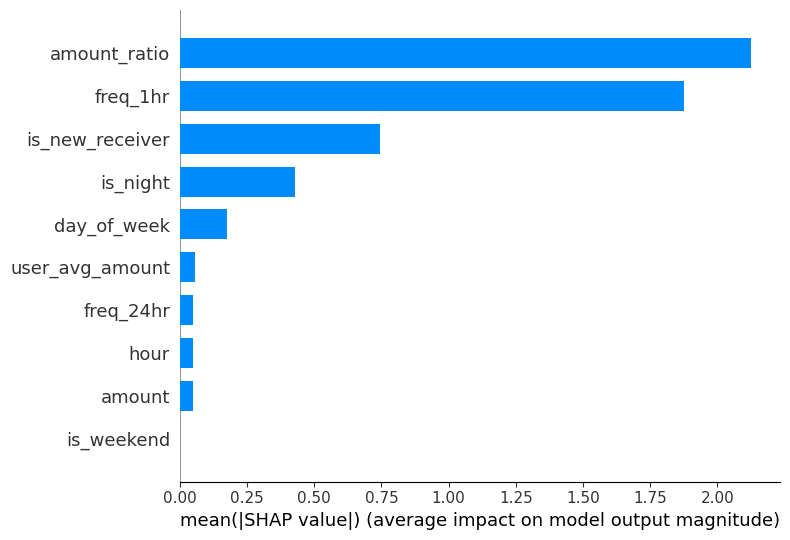


SHAP done!

Saving model...
✅ Model saved!
✅ Scaler saved!
✅ SHAP explainer saved!
✅ Feature names saved!

Saved files: ['feature_names.json', 'feature_names_v2.json', 'fraud_model.pkl', 'fraud_model_v2.pkl', 'scaler_v2.pkl', 'shap_explainer.pkl', 'shap_explainer_v2.pkl']


In [5]:
import shap
import pickle
import json

print("Calculating SHAP values...")
explainer = shap.TreeExplainer(model)
X_test_sample = X_test_scaled[:100]
shap_values = explainer.shap_values(X_test_sample)

# Plot feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:100],
                  feature_names=X.columns.tolist(),
                  plot_type="bar", show=True)

print("\nSHAP done!")

# Save everything
print("\nSaving model...")
pickle.dump(model, open('../models/fraud_model_v2.pkl', 'wb'))
pickle.dump(scaler, open('../models/scaler_v2.pkl', 'wb'))
pickle.dump(explainer, open('../models/shap_explainer_v2.pkl', 'wb'))

feature_names = X.columns.tolist()
with open('../models/feature_names_v2.json', 'w') as f:
    json.dump(feature_names, f)

print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ SHAP explainer saved!")
print("✅ Feature names saved!")

# Verify
import os
files = os.listdir('../models/')
print("\nSaved files:", files)